In [1]:
import os
import cv2
import shap
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import euclidean
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score,  
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

os.environ["VERBOSE"] = "-1"
os.environ["LIGHTGBM_VERBOSE"] = "-1"

print(os.getcwd())

D:\GITDEMO\Gaze_Detection


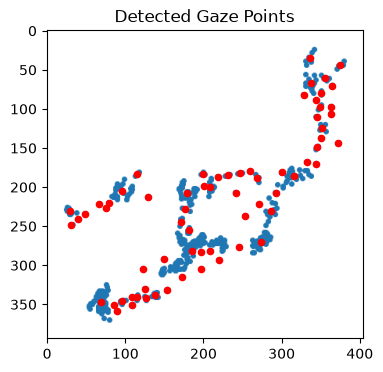

Number of fixations: 55
Fixations:
 [[ 37.25       238.5       ]
 [ 67.         222.        ]
 [ 69.         347.        ]
 [ 77.         223.5       ]
 [ 87.5        355.        ]
 [ 96.         205.        ]
 [104.33333333 346.        ]
 [115.         183.        ]
 [115.         341.        ]
 [123.         305.        ]
 [125.5        336.        ]
 [129.         213.        ]
 [138.         338.        ]
 [149.         292.        ]
 [154.         331.        ]
 [171.         244.        ]
 [173.         315.        ]
 [177.         228.        ]
 [179.         208.        ]
 [181.         255.        ]
 [185.         282.        ]
 [197.         305.        ]
 [197.         283.        ]
 [200.         191.        ]
 [208.         282.        ]
 [213.5        193.5       ]
 [220.         293.        ]
 [231.         185.        ]
 [241.         207.        ]
 [246.         277.        ]
 [247.         182.        ]
 [253.         237.        ]
 [264.         184.        ]
 [271. 

In [2]:
image_path = 'D:/GITDEMO/Gaze_Detection/test.png'

if not os.path.isfile(image_path):
    raise FileNotFoundError(f"File not found: {image_path}")

image = cv2.imread(image_path)

if image is None:
    raise ValueError("Image could not be read properly")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Adaptive threshold 
binary = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11, 2
)

# Find contours
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

gaze_points = []

for contour in contours:
    M = cv2.moments(contour)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        gaze_points.append((cx, cy))

gaze_points = np.array(gaze_points)

# Safety check 
if len(gaze_points) == 0:
    raise ValueError("No gaze points detected")

# Sort by x-axis (keeps scan order stable
gaze_points = gaze_points[np.argsort(gaze_points[:, 0])]

# Visualization
plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.scatter(gaze_points[:, 0], gaze_points[:, 1], s=20, c='red')
plt.title('Detected Gaze Points')
plt.show()

# FIXATION DETECTION 

def calculate_fixations(points, threshold=20):
    if len(points) < 2:
        return points

    fixations = []
    current = [points[0]]

    for p in points[1:]:
        if euclidean(p, current[-1]) <= threshold:
            current.append(p)
        else:
            fixations.append(np.mean(current, axis=0))
            current = [p]

    if len(current) > 0:
        fixations.append(np.mean(current, axis=0))

    return np.array(fixations)

fixations = calculate_fixations(gaze_points)

print("Number of fixations:", len(fixations))
print("Fixations:\n", fixations)


FINAL PREDICTION
Character  : J
Score      : 0.8115
Confidence : 33.89 %
Region     : RIGHT

TOP 3
Character    score  confidence
        J 0.811463   33.893493
        T 0.689279   27.462477
        N 0.689233   27.460584


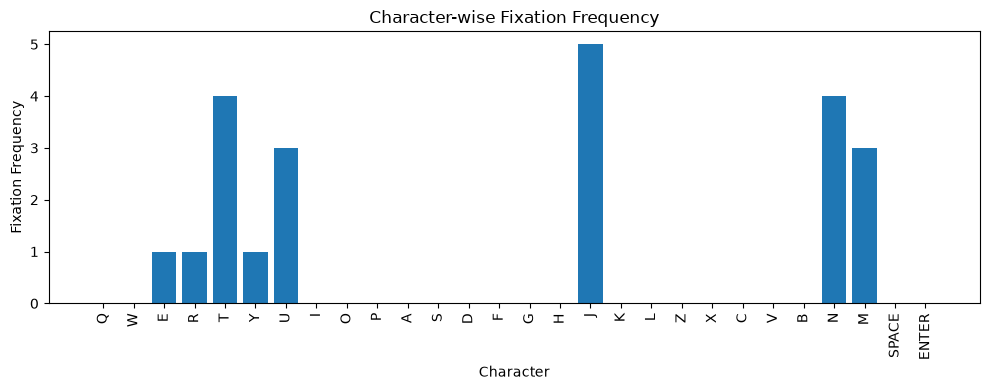

In [3]:
# LOAD DATA
df = pd.read_csv("keyboard coordinates.csv")

mid_x = (df["X_MIN"].min() + df["X_MAX"].max()) / 2

# REGION FUNCTION 
def get_region(x):
    return "LEFT" if x < mid_x else "RIGHT"

# CHECK FIXATION INSIDE KEY REGION
def is_inside(fix, row):
    x, y = fix
    return (row["X_MIN"] <= x <= row["X_MAX"]) and (row["Y_MIN"] <= y <= row["Y_MAX"])

# FIXATION FREQUENCY + DISTANCE + REGION
df["fixation_frequency"] = 0
df["avg_distance"] = 0
df["region_score"] = 0   

for i, row in df.iterrows():

    inside_fix = [f for f in fixations if is_inside(f, row)]

    df.at[i, "fixation_frequency"] = len(inside_fix)

    # distance
    if len(inside_fix) > 0:
        cx = (row["X_MIN"] + row["X_MAX"]) / 2
        cy = (row["Y_MIN"] + row["Y_MAX"]) / 2

        dist = [np.sqrt((f[0]-cx)**2 + (f[1]-cy)**2) for f in inside_fix]
        df.at[i, "avg_distance"] = np.mean(dist)
    else:
        df.at[i, "avg_distance"] = 1e6

    # REGION FEATURE 
    key_region = get_region((row["X_MIN"] + row["X_MAX"]) / 2)

    if len(inside_fix) > 0:
        r_scores = []

        for f in inside_fix:
            gaze_region = get_region(f[0])

            if gaze_region == key_region:
                r_scores.append(1.0)   
            else:
                r_scores.append(0.5)   

        df.at[i, "region_score"] = np.mean(r_scores)
    else:
        df.at[i, "region_score"] = 0

# FEATURE NORMALIZATION
df["freq_norm"] = df["fixation_frequency"] / (df["fixation_frequency"].max() + 1e-6)
df["dist_score"] = 1 / (df["avg_distance"] + 1e-6)

# 5. RAW SCORE 
df["score"] = (
    0.6 * df["freq_norm"] +
    0.2 * df["dist_score"] +
    0.2 * df["region_score"]
)

# CONFIDENCE MODEL 
temperature = 0.25
scores = df["score"].values

exp_scores = np.exp((scores - np.max(scores)) / temperature)
df["prob"] = exp_scores / np.sum(exp_scores)

sorted_scores = np.sort(scores)[::-1]
top1, top2 = sorted_scores[0], sorted_scores[1]

margin = (top1 - top2) / (top1 + 1e-6)
margin_conf = 0.5 + 0.5 * margin

df["confidence"] = (0.7 * df["prob"] + 0.3 * margin_conf) * 100

# FINAL PREDICTION
best_idx = df["confidence"].idxmax()
best_char = df.loc[best_idx]

# predicted region
pred_region = get_region((best_char["X_MIN"] + best_char["X_MAX"]) / 2)

top3 = df.nlargest(3, "confidence")[["Character", "score", "confidence"]]

# OUTPUT
print("\nFINAL PREDICTION")
print("Character  :", best_char["Character"])
print("Score      :", round(best_char["score"], 4))
print("Confidence :", round(best_char["confidence"], 2), "%")
print("Region     :", pred_region)   

print("\nTOP 3")
print(top3.to_string(index=False))

# FIXATION FREQUENCY BAR CHART
plt.figure(figsize=(10, 4))
plt.bar(df["Character"], df["fixation_frequency"])
plt.xticks(rotation=90)
plt.xlabel("Character")
plt.ylabel("Fixation Frequency")
plt.title("Character-wise Fixation Frequency")
plt.tight_layout()
plt.show()

In [4]:
data = pd.read_csv('normalized_dataset_finall.csv')

data['Character'] = data['Character'].str.strip()

X_raw = data.drop(columns=['Image name', 'Character']).values
y_raw = data['Character'].values

label_encoder = LabelEncoder()
y_encoded_raw = label_encoder.fit_transform(y_raw)


def augment_data(X, y, factor=5):
    np.random.seed(42)
    parts_X, parts_y = [X], [y]

    for _ in range(factor - 1):
        noise = X + np.random.normal(0, 0.05, X.shape)
        shift = X + np.random.uniform(-0.3, 0.3, X.shape)
        scale = X * np.random.uniform(0.98, 1.02, X.shape)

        parts_X += [noise, shift, scale]
        parts_y += [y, y, y]

        if len(np.vstack(parts_X)) >= len(X) * factor:
            break

    return np.vstack(parts_X), np.hstack(parts_y)


X_aug, y_aug = augment_data(X_raw, y_encoded_raw, factor=5)


X_train, X_test, y_train, y_test = train_test_split(
    X_aug,
    y_aug,
    test_size=0.2,
    random_state=42,
    stratify=y_aug
)

In [11]:
class AdvancedEnsemble(BaseEstimator, ClassifierMixin):

    def __init__(self, n_classes=None):
        self.n_classes = n_classes
        self.meta = LogisticRegression(
            max_iter=500,
            C=0.5
        )

    def fit(self, X, y):

        self.le = LabelEncoder()
        y_enc = self.le.fit_transform(y)

        n_classes = len(np.unique(y_enc))

        # =========================
        # XGBoost
        # =========================
        self.xgb = XGBClassifier(
            n_estimators=150,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.7,
            colsample_bytree=0.7,
            objective="multi:softprob",
            num_class=n_classes,
            eval_metric="mlogloss",
            random_state=42
        )

        # =========================
        # LightGBM
        # =========================
        self.lgbm = LGBMClassifier(
            n_estimators=150,
            learning_rate=0.05,
            num_leaves=25,
            max_depth=8,
            min_child_samples=20,
            random_state=42,
            verbose=-1
        )

        # =========================
        # SVM
        # =========================
        self.svm = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(
                kernel="rbf",
                C=0.5,
                gamma="scale",
                probability=True,
                random_state=42
            ))
        ])

        # =========================
        # 5-Fold Meta Feature Generation
        # =========================
        kf = KFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        meta_features = np.zeros(
            (X.shape[0], n_classes * 3)
        )

        for tr, val in kf.split(X):

            X_tr, X_val = X[tr], X[val]
            y_tr = y_enc[tr]

            # Train base models
            self.xgb.fit(X_tr, y_tr)
            self.lgbm.fit(X_tr, y_tr)
            self.svm.fit(X_tr, y_tr)

            # Generate out-of-fold predictions
            xgb_prob = self.xgb.predict_proba(X_val)
            lgbm_prob = self.lgbm.predict_proba(X_val)
            svm_prob = self.svm.predict_proba(X_val)

            # Combine base-model predictions
            meta_features[val] = np.hstack([
                xgb_prob,
                lgbm_prob,
                svm_prob
            ])

        # =========================
        # Train Meta Learner
        # =========================
        self.meta.fit(
            meta_features,
            y_enc
        )

        # =========================
        # Retrain Base Models
        # on Full Training Data
        # =========================
        self.xgb.fit(
            X,
            y_enc
        )

        self.lgbm.fit(
            X,
            y_enc
        )

        self.svm.fit(
            X,
            y_enc
        )

        return self

    def predict(self, X):

        # Base model probabilities
        xgb_prob = self.xgb.predict_proba(X)
        lgbm_prob = self.lgbm.predict_proba(X)
        svm_prob = self.svm.predict_proba(X)

        # Meta features
        meta_X = np.hstack([
            xgb_prob,
            lgbm_prob,
            svm_prob
        ])

        # Final prediction
        pred = self.meta.predict(meta_X)

        # Convert encoded labels back
        return self.le.inverse_transform(pred)

In [12]:
model = AdvancedEnsemble()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9116279069767442


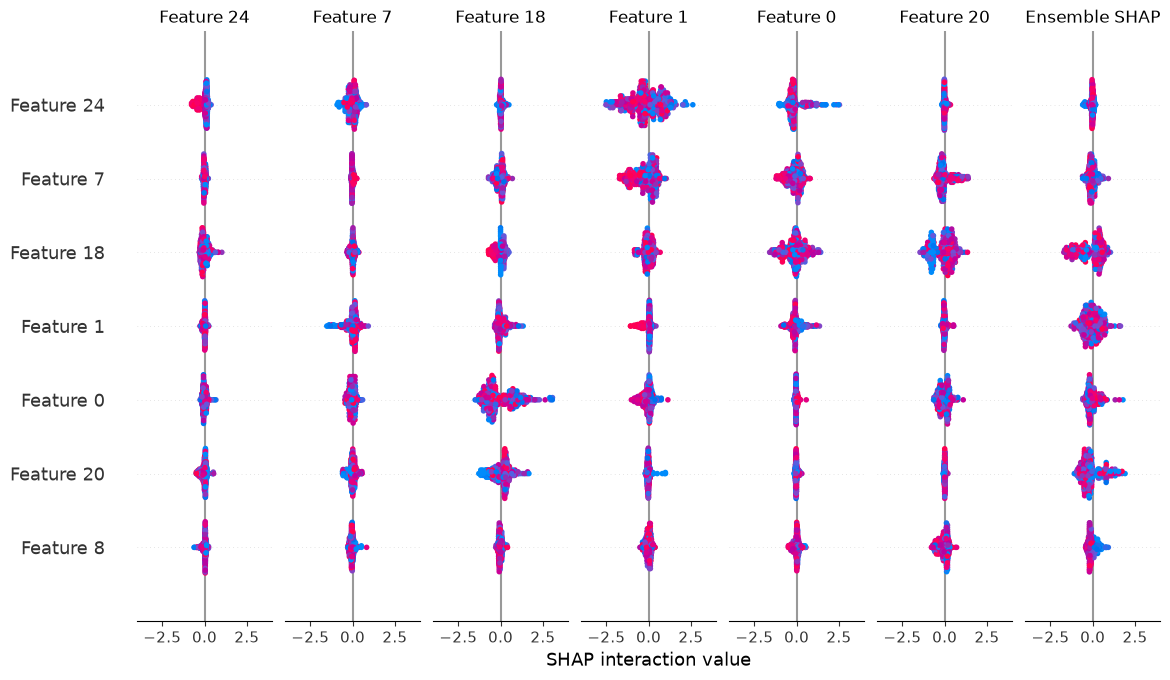

In [13]:
xgb_shap = shap.TreeExplainer(model.xgb).shap_values(X_test)
lgbm_shap = shap.TreeExplainer(model.lgbm).shap_values(X_test)

combined_shap = np.mean([xgb_shap, lgbm_shap], axis=0)

shap.summary_plot(combined_shap, X_test, show=False)
plt.title("Ensemble SHAP")
plt.show()

In [14]:
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

clients = []

for tr, _ in kf.split(X_train, y_train):

    m = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )

    m.fit(X_train[tr], y_train[tr])
    clients.append(m)

preds = np.mean(
    [m.predict_proba(X_test) for m in clients],
    axis=0
)

fl_pred = np.argmax(preds, axis=1)

print("FL Accuracy:", accuracy_score(y_test, fl_pred))

FL Accuracy: 0.8767441860465116


In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for fold, (tr, val) in enumerate(skf.split(X_train, y_train), 1):

    model_cv = AdvancedEnsemble()

    model_cv.fit(X_train[tr], y_train[tr])

    pred = model_cv.predict(X_train[val])

    acc = accuracy_score(y_train[val], pred)

    scores.append(acc)

    print(f"Fold {fold}: {acc:.4f}")

print("Mean:", np.mean(scores))
print("Std:", np.std(scores))

Fold 1: 0.8110
Fold 2: 0.8169
Fold 3: 0.8488
Fold 4: 0.8052
Fold 5: 0.8047
Mean: 0.8173282934436232
Std: 0.0163655996091182


In [ ]:
# FL Topologies comparison 

from copy import deepcopy

kf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

client_data = [
    (X_train[idx], y_train[idx])
    for idx, _ in kf.split(X_train, y_train)
]

# HELPER FUNCTION
def create_client_model():

    return LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )

# TOPOLOGY 1 : PARALLEL FEDAVG FL

parallel_models = []

for Xc, yc in client_data:

    model = create_client_model()
    model.fit(Xc, yc)

    parallel_models.append(model)

parallel_pred = np.mean(
    [m.predict_proba(X_test) for m in parallel_models],
    axis=0
)

parallel_acc = accuracy_score(
    y_test,
    np.argmax(parallel_pred, axis=1)
)

# TOPOLOGY 2 : SEQUENTIAL CHAIN FL

chain_model = create_client_model()

for i, (Xc, yc) in enumerate(client_data):

    chain_model.fit(
        Xc,
        yc,
        init_model=None if i == 0 else chain_model.booster_
    )

chain_acc = accuracy_score(
    y_test,
    chain_model.predict(X_test)
)

# TOPOLOGY 3 : HIERARCHICAL FL

client_models = []

for Xc, yc in client_data:

    model = create_client_model()
    model.fit(Xc, yc)

    client_models.append(model)

C1, C2, C3 = client_models

# Level 1 aggregation
agg_left = np.mean([
    C1.predict_proba(X_test),
    C2.predict_proba(X_test)
], axis=0)

agg_right = np.mean([
    C1.predict_proba(X_test),
    C3.predict_proba(X_test)
], axis=0)

# Level 2 aggregation
agg_center = np.mean([
    agg_left,
    agg_right
], axis=0)

# Server aggregation
hierarchical_pred = np.argmax(
    agg_center,
    axis=1
)

hierarchical_acc = accuracy_score(
    y_test,
    hierarchical_pred
)

# RESULTS

results_df = pd.DataFrame({
    "Topology": [
        "Parallel FedAvg FL",
        "Sequential Chain FL",
        "Hierarchical FL"
    ],
    "Accuracy": [
        parallel_acc,
        chain_acc,
        hierarchical_acc
    ]
})

print("\nFL TOPOLOGY COMPARISON\n")
print(results_df)


# VISUALIZATION

plt.figure(figsize=(10, 5))

bars = plt.bar(
    results_df["Topology"],
    results_df["Accuracy"]
)

for b in bars:

    h = b.get_height()

    plt.text(
        b.get_x() + b.get_width()/2,
        h,
        f"{h:.4f}",
        ha='center'
    )

plt.ylabel("Accuracy")
plt.title("Federated Learning Topology Comparison (3 Clients)")
plt.xticks(rotation=10)

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results = []

# 1. STACKING ENSEMBLE

full_model = AdvancedEnsemble(
    n_classes=len(np.unique(y_train))
)

full_model.fit(X_train, y_train)

pred_full = full_model.predict(X_test)

acc_full = accuracy_score(
    y_test,
    pred_full
)

f1_full = f1_score(
    y_test,
    pred_full,
    average="weighted",
    zero_division=0
)

results.append([
    "Stacking Ensemble (Proposed)",
    acc_full * 100,
    f1_full
])

# 2. XGBOOST

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.7,
    objective="multi:softprob",
    num_class=len(np.unique(y_train)),
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

acc_xgb = accuracy_score(
    y_test,
    pred_xgb
)

f1_xgb = f1_score(
    y_test,
    pred_xgb,
    average="weighted",
    zero_division=0
)

results.append([
    "XGBoost",
    acc_xgb * 100,
    f1_xgb
])

# 3. LIGHTGBM

lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=5,
    max_depth=4,
    random_state=42,
    verbose=-1
)

lgbm.fit(X_train, y_train)

pred_lgbm = lgbm.predict(X_test)

acc_lgbm = accuracy_score(
    y_test,
    pred_lgbm
)

f1_lgbm = f1_score(
    y_test,
    pred_lgbm,
    average="weighted",
    zero_division=0
)

results.append([
    "LightGBM",
    acc_lgbm * 100,
    f1_lgbm
])

# 4. SVM

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1,
        probability=True
    ))
])

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(
    y_test,
    pred_svm
)

f1_svm = f1_score(
    y_test,
    pred_svm,
    average="weighted",
    zero_division=0
)

results.append([
    "SVM",
    acc_svm * 100,
    f1_svm
])

# FINAL TABLE

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy (%)",
        "F1-Score"
    ]
)

print("\nMODEL COMPARISON")
print(results_df)

# BEST MODEL

best_idx = results_df["Accuracy (%)"].idxmax()

print("\nBEST MODEL")
print(results_df.loc[best_idx])

# VISUALIZATION

plt.figure(figsize=(10,5))

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy (%)"]
)

for bar in bars:

    h = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f"{h:.2f}",
        ha='center'
    )

plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.xticks(rotation=20)

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

results = []
cv_scores = []

# =========================
# Helper: Cross Validation
# =========================
def get_cv_score(model_fn):

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for tr, val in skf.split(X_train, y_train):

        model = model_fn()
        model.fit(X_train[tr], y_train[tr])
        pred = model.predict(X_train[val])

        scores.append(
            accuracy_score(y_train[val], pred)
        )

    return np.mean(scores), np.std(scores)


# =========================
# 1. XGBOOST
# =========================
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.7,
    objective="multi:softprob",
    num_class=len(np.unique(y_train)),
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_test)

results.append([
    "XGBoost",
    accuracy_score(y_test, pred_xgb) * 100,
    f1_score(y_test, pred_xgb, average="weighted"),
    precision_score(y_test, pred_xgb, average="weighted", zero_division=0),
    recall_score(y_test, pred_xgb, average="weighted", zero_division=0)
])

cv_scores.append(get_cv_score(lambda: xgb_model))


# =========================
# 2. LIGHTGBM
# =========================
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=15,
    max_depth=4,
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)
pred_lgbm = lgbm_model.predict(X_test)

results.append([
    "LightGBM",
    accuracy_score(y_test, pred_lgbm) * 100,
    f1_score(y_test, pred_lgbm, average="weighted"),
    precision_score(y_test, pred_lgbm, average="weighted", zero_division=0),
    recall_score(y_test, pred_lgbm, average="weighted", zero_division=0)
])

cv_scores.append(get_cv_score(lambda: LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=15,
    max_depth=4,
    random_state=42,
    verbose=-1
)))


# =========================
# 3. SVM
# =========================
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1, probability=True))
])

svm_model.fit(X_train, y_train)
pred_svm = svm_model.predict(X_test)

results.append([
    "SVM",
    accuracy_score(y_test, pred_svm) * 100,
    f1_score(y_test, pred_svm, average="weighted"),
    precision_score(y_test, pred_svm, average="weighted", zero_division=0),
    recall_score(y_test, pred_svm, average="weighted", zero_division=0)
])

cv_scores.append(get_cv_score(lambda: Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1, probability=True))
])))


# =========================
# 4. STACKING ENSEMBLE
# =========================
stack_model = AdvancedEnsemble()
stack_model.fit(X_train, y_train)
pred_stack = stack_model.predict(X_test)

results.append([
    "Stacking Ensemble (Proposed)",
    accuracy_score(y_test, pred_stack) * 100,
    f1_score(y_test, pred_stack, average="weighted"),
    precision_score(y_test, pred_stack, average="weighted", zero_division=0),
    recall_score(y_test, pred_stack, average="weighted", zero_division=0)
])

cv_scores.append(get_cv_score(lambda: AdvancedEnsemble()))


# =========================
# FINAL TABLE
# =========================
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy (%)",
        "F1-Score",
        "Precision",
        "Recall"
    ]
)

results_df["CV Mean Accuracy (%)"] = [c[0]*100 for c in cv_scores]
results_df["STD"] = [c[1]*100 for c in cv_scores]

print("\nMODEL COMPARISON TABLE\n")
print(results_df)


# =========================
# FINAL MODEL METRICS
# =========================

best_model_idx = results_df["Accuracy (%)"].idxmax()
best_model = results_df.iloc[best_model_idx]

print("\n========================")
print("FINAL MODEL REPORT")
print("========================")

print("Overall Accuracy (Final Model):", round(best_model["Accuracy (%)"], 2), "%")
print("F1-Score (Final Model):", round(best_model["F1-Score"], 4))
print("Precision:", round(best_model["Precision"], 4))
print("Recall:", round(best_model["Recall"], 4))
print("Cross-Validation Mean Accuracy:", round(best_model["CV Mean Accuracy (%)"], 2), "%")
print("Standard Deviation:", round(best_model["STD"], 2))


# =========================
# PLOT
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["Accuracy (%)"])

for i, v in enumerate(results_df["Accuracy (%)"]):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.title("Model Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=20)
plt.show()

In [1]:
import pandas as pd  
df = pd.read_csv('normalized_dataset_finall.csv')

In [2]:
df.shape

(307, 64)

In [3]:
df.columns

Index(['Image name', 'Fixation X coordinate 01', 'Fixation X coordinate 02',
       'Fixation X coordinate 03', 'Fixation X coordinate 04',
       'Fixation X coordinate 05', 'Fixation X coordinate 06',
       'Fixation X coordinate 07', 'Fixation X coordinate 08',
       'Fixation X coordinate 09', 'Fixation X coordinate 10',
       'Fixation X coordinate 11', 'Fixation X coordinate 12',
       'Fixation X coordinate 13', 'Fixation X coordinate 14',
       'Fixation X coordinate 15', 'Fixation X coordinate 16',
       'Fixation X coordinate 17', 'Fixation X coordinate 18',
       'Fixation X coordinate 19', 'Fixation X coordinate 20',
       'Fixation X coordinate 21', 'Fixation X coordinate 22',
       'Fixation X coordinate 23', 'Fixation X coordinate 24',
       'Fixation X coordinate 25', 'Fixation X coordinate 26',
       'Fixation X coordinate 27', 'Fixation X coordinate 28',
       'Fixation X coordinate 29', 'Fixation X coordinate 30',
       'Fixation Y coordinate 01', 'Fixat